## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [138]:
## importing important libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import seaborn as sns

In [139]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\ML Model Implementations\13_Gradient_Boosting\Classification\Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Columns Information

| 🔢 No. | Column Name              | Description                         | Type                   | Values / Notes                                        |
| ------ | ------------------------ | ----------------------------------- | ---------------------- | ----------------------------------------------------- |
| 1      | CustomerID               | Unique identifier for each customer | Integer                | Not useful for model (drop)                           |
| 2      | ProdTaken 🎯             | Target variable (purchase or not)   | Binary                 | 1 = Yes, 0 = No                                       |
| 3      | Age                      | Age of customer                     | Numerical (Continuous) | —                                                     |
| 4      | TypeofContact            | Mode of contact                     | Categorical            | Company Invited, Self Inquiry                         |
| 5      | CityTier                 | City category                       | Ordinal                | 1 = Metro, 2 = Tier-2, 3 = Tier-3                     |
| 6      | DurationOfPitch          | Duration of sales pitch (minutes)   | Numerical              | —                                                     |
| 7      | Occupation               | Customer occupation                 | Categorical            | Salaried, Small Business, Large Business, Free Lancer |
| 8      | Gender                   | Gender of customer                  | Categorical            | Male, Female                                          |
| 9      | NumberOfPersonVisiting   | Total people traveling              | Numerical (Discrete)   | —                                                     |
| 10     | NumberOfFollowups        | Follow-up calls count               | Numerical (Discrete)   | —                                                     |
| 11     | ProductPitched           | Type of product offered             | Categorical            | Basic, Standard, Deluxe, Super Deluxe, King           |
| 12     | PreferredPropertyStar    | Preferred hotel rating              | Ordinal                | 1 to 5                                                |
| 13     | MaritalStatus            | Marital status                      | Categorical            | Married, Single, Divorced                             |
| 14     | NumberOfTrips            | Trips per year                      | Numerical              | —                                                     |
| 15     | Passport                 | Has passport or not                 | Binary                 | 1 = Yes, 0 = No                                       |
| 16     | PitchSatisfactionScore   | Satisfaction after pitch            | Ordinal                | 1 to 5                                                |
| 17     | OwnCar                   | Owns a car or not                   | Binary                 | 1 = Yes, 0 = No                                       |
| 18     | NumberOfChildrenVisiting | Children traveling                  | Numerical              | —                                                     |
| 19     | Designation              | Job level                           | Ordinal                | Executive → VP                                        |
| 20     | MonthlyIncome            | Monthly income                      | Numerical              | Strong feature                                        |


In [140]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [141]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [142]:
df.duplicated().sum()

0

In [143]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [144]:
df['Gender']=df['Gender'].replace("Fe Male", "Female")

In [145]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [146]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [147]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus',
    'Designation'
]

binary_cols = [
    'Passport',
    'OwnCar',
    'ProdTaken'
]

discrete_cols = [
    'CityTier',
    'NumberOfFollowups',
    'PreferredPropertyStar',
    'PitchSatisfactionScore'
]

for col in categorical_cols + binary_cols + discrete_cols:
    print(f"\n-> {col} Value Counts:\n")
    print(df[col].value_counts())


-> TypeofContact Value Counts:

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

-> Occupation Value Counts:

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

-> Gender Value Counts:

Gender
Male      2916
Female    1972
Name: count, dtype: int64

-> ProductPitched Value Counts:

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

-> MaritalStatus Value Counts:

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

-> Designation Value Counts:

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

-> Passport Value Counts:

Passport
0    3466
1    1422
Name: count, dtype: int64

-> OwnCar Value Counts:

OwnCar
1    3

In [148]:
df['MaritalStatus']=df['MaritalStatus'].replace('Single', 'Unmarried')

In [149]:
df['MaritalStatus'].unique()

array(['Unmarried', 'Divorced', 'Married'], dtype=object)

In [150]:
numerical_cols = [
    'Age',
    'DurationOfPitch',
    'NumberOfTrips',
    'MonthlyIncome',
    'NumberOfPersonVisiting',
    'NumberOfChildrenVisiting'
]

df[numerical_cols].describe()

,Age,DurationOfPitch,NumberOfTrips,MonthlyIncome,NumberOfPersonVisiting,NumberOfChildrenVisiting
count,4662.000000,4637.000000,4748.000000,4655.000000,4888.000000,4822.000000
mean,37.622265,15.490835,3.236521,23619.853491,2.905074,1.187267
std,9.316387,8.519643,1.849019,5380.698361,0.724891,0.857861
min,18.000000,5.000000,1.000000,1000.000000,1.000000,0.000000
25%,31.000000,9.000000,2.000000,20346.000000,2.000000,1.000000
50%,36.000000,13.000000,3.000000,22347.000000,3.000000,1.000000
75%,44.000000,20.000000,4.000000,25571.000000,3.000000,2.000000
max,61.000000,127.000000,22.000000,98678.000000,5.000000,3.000000


In [151]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

## Filling Missing Values

In [152]:
# For age
value=df['Age'].mean()
df.fillna({'Age': value}, inplace=True)

In [153]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                           0
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [154]:
df['TypeofContact'].mode()[0]

'Self Enquiry'

In [155]:
df['TypeofContact'] = df['TypeofContact'].fillna(df['TypeofContact'].mode()[0])

In [156]:
df['NumberOfFollowups'] = df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].median())

In [157]:
df['NumberOfTrips'] = df['NumberOfTrips'].fillna(df['NumberOfTrips'].median())

In [158]:
df['NumberOfChildrenVisiting'] = df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].median())

In [159]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

In [160]:
df['PreferredPropertyStar'] = df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].median())

In [161]:
df['DurationOfPitch'] = df['DurationOfPitch'].fillna(df['DurationOfPitch'].median())

In [162]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [163]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [164]:
df.drop('CustomerID', inplace=True, axis=1)

In [165]:
df.dtypes

ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

# Feature Engineering 

In [191]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'object']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 13


In [192]:
## categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == "object"]
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 6


In [193]:
## Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 10


In [194]:
## coontinuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 3


In [170]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [171]:
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

In [172]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus'
]

ordinal_cols = [
    'Designation',
    'CityTier',
    'PreferredPropertyStar'
]

numerical_cols = [
    col for col in X.columns if col not in categorical_cols + ordinal_cols
]

In [173]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((3910, 18), (978, 18))

In [174]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       4888 non-null   float64
 1   TypeofContact             4888 non-null   object 
 2   CityTier                  4888 non-null   int64  
 3   DurationOfPitch           4888 non-null   float64
 4   Occupation                4888 non-null   object 
 5   Gender                    4888 non-null   object 
 6   NumberOfPersonVisiting    4888 non-null   int64  
 7   NumberOfFollowups         4888 non-null   float64
 8   ProductPitched            4888 non-null   object 
 9   PreferredPropertyStar     4888 non-null   float64
 10  MaritalStatus             4888 non-null   object 
 11  NumberOfTrips             4888 non-null   float64
 12  Passport                  4888 non-null   int64  
 13  PitchSatisfactionScore    4888 non-null   int64  
 14  OwnCar  

### Encode Categorical 

In [175]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [176]:
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

X_train_cat

array([[1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [177]:
# Convert to DataFrame
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_feature_names)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=cat_feature_names)

In [178]:
X_train_cat_df.head()

,TypeofContact_Self Enquiry,Occupation_Large Business,Occupation_Salaried,Occupation_Small Business,Gender_Male,ProductPitched_Deluxe,ProductPitched_King,ProductPitched_Standard,ProductPitched_Super Deluxe,MaritalStatus_Married,MaritalStatus_Unmarried
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Encode Ordinal

In [179]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder()

X_train_ord = ord_encoder.fit_transform(X_train[ordinal_cols])
X_test_ord = ord_encoder.transform(X_test[ordinal_cols])

X_train_ord

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 2.],
       ...,
       [1., 2., 0.],
       [2., 2., 0.],
       [1., 0., 0.]])

In [180]:
# Convert to DataFrame
X_train_ord_df = pd.DataFrame(X_train_ord, columns=ordinal_cols)
X_test_ord_df = pd.DataFrame(X_test_ord, columns=ordinal_cols)

X_train_ord_df.head()

,Designation,CityTier,PreferredPropertyStar
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,2.0
3,2.0,0.0,0.0
4,1.0,0.0,0.0


In [181]:
designation_order = ["Executive", "Manager", "Senior Manager", "AVP", "VP"]

ord_encoder = OrdinalEncoder(categories=[
    designation_order,  # Designation
    [1, 2, 3],          # CityTier
    [1, 2, 3, 4, 5]     # PreferredPropertyStar
])

### Combine All Features

In [182]:
X_train_final = pd.concat([
    X_train[numerical_cols].reset_index(drop=True),
    X_train_ord_df.reset_index(drop=True),
    X_train_cat_df.reset_index(drop=True)
], axis=1)

X_test_final = pd.concat([
    X_test[numerical_cols].reset_index(drop=True),
    X_test_ord_df.reset_index(drop=True),
    X_test_cat_df.reset_index(drop=True)
], axis=1)

In [183]:
feature_names = list(X_train_final.columns)
feature_names

['Age',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'Designation',
 'CityTier',
 'PreferredPropertyStar',
 'TypeofContact_Self Enquiry',
 'Occupation_Large Business',
 'Occupation_Salaried',
 'Occupation_Small Business',
 'Gender_Male',
 'ProductPitched_Deluxe',
 'ProductPitched_King',
 'ProductPitched_Standard',
 'ProductPitched_Super Deluxe',
 'MaritalStatus_Married',
 'MaritalStatus_Unmarried']

### Train the model

In [184]:
!pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [185]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

model.fit(X_train_final, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [186]:
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [187]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8558282208588958

Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.92       787
           1       0.78      0.37      0.50       191

    accuracy                           0.86       978
   macro avg       0.82      0.67      0.71       978
weighted avg       0.85      0.86      0.83       978


Confusion Matrix: 
 [[767  20]
 [121  70]]


# Hyperparameter Tunning

In [203]:
xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [204]:
xgboost_params

{'learning_rate': [0.1, 0.01],
 'max_depth': [5, 8, 12, 20, 30],
 'n_estimators': [100, 200, 300],
 'colsample_bytree': [0.5, 0.8, 1, 0.3, 0.4]}

In [205]:
# Models list for Hyperparameter tuning
randomcv_models = [("Xgboost", XGBClassifier(), xgboost_params)]

In [206]:
randomcv_models

[('Xgboost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  {'learning_rate': [0.1, 0.01],
   'max_depth': [5, 8, 12, 20, 30],
   'n_estimators': [100, 200, 300],
   'colsample_bytree': [0.5, 0.8, 1, 0.3, 0.4]})]

In [208]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train_final, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for Xgboost -------------------
{'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 1}


In [210]:
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [214]:
models={
    "Xgboost":XGBClassifier(n_estimators=300,max_depth=12,learning_rate=0.1,
                           colsample_bytree=1)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_final, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_final)
    y_test_pred = model.predict(X_test_final)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Xgboost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9499
- F1 score: 0.9479
- Precision: 0.9551
- Recall: 0.7801
- Roc Auc Score: 0.8856




In [217]:
print(confusion_matrix(y_test, y_test_pred))

[[780   7]
 [ 42 149]]


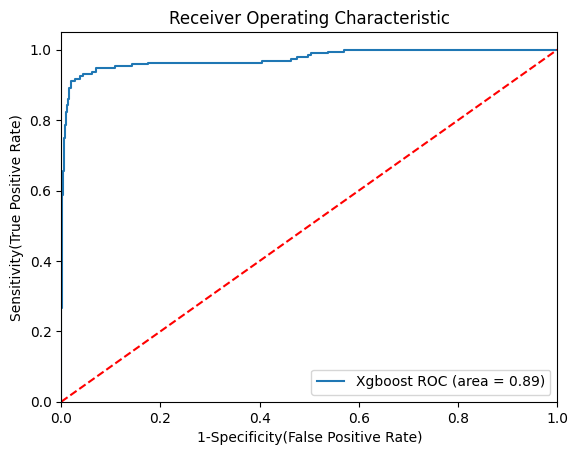

In [221]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Xgboost',
    'model':XGBClassifier(n_estimators=200,max_depth=12,learning_rate=0.1,
                           colsample_bytree=1),
    'auc':  0.8882
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train_final, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_final)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 